In [159]:
import torch
import torch.nn as nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from tqdm.auto import tqdm

In [160]:
class CNNFashionModel(nn.Module):
    def __init__(self, input_size:int, hidden_size:int, output_size:int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(input_size, hidden_size, 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(hidden_size, hidden_size, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_size, hidden_size, 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(hidden_size, hidden_size, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_size*7*7, output_size) # 28 14 7
        )
    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        return self.classifier(x)




In [161]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CNNFashionModel(1, 32, 10).to(device)

In [162]:
train_data = datasets.FashionMNIST(
    "data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    "data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

In [163]:
BATCH_SIZE = 256

train_dataloader = DataLoader(train_data, BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, BATCH_SIZE, shuffle=False)
len(test_dataloader)


40

In [164]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
print(len(train_features_batch), len(train_labels_batch))
print(train_features_batch.shape, train_labels_batch.shape)
class_names = train_data.classes
print(class_names)


256 256
torch.Size([256, 1, 28, 28]) torch.Size([256])
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


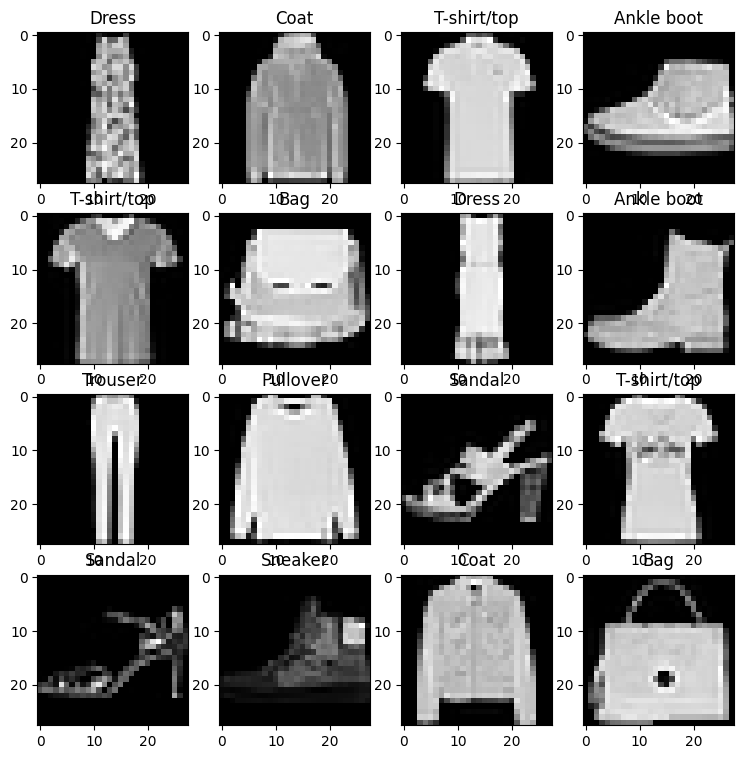

In [165]:
fig, axes = plt.subplots(4, 4, figsize  = (9,9))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(train_features_batch[i].squeeze(), cmap = "gray")
    ax.set_title(class_names[train_labels_batch[i].item()])

In [166]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = .001)

In [167]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

CNNFashionModel(
  (block_1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=10, bias=True)
  )
)

In [168]:
str(next(model.parameters()).device)

'cuda:0'

In [169]:
load_model = True
if load_model:
    model.load_state_dict(torch.load("CNN_Fashion_model.pth", weights_only = True))

In [170]:
epochs = 2

for epoch in tqdm(range(epochs)):

    acc = 0
    
    for batch, (X,y) in enumerate(train_dataloader):
        X , y = X.to(device), y.to(device)
        model.train()
        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

        if batch % 40 ==0:
            print(f"{batch * train_dataloader.batch_size} / {len(train_data)}")
        acc += (pred.argmax(dim=1) == y).to(float).mean().item()
    acc /= len(train_dataloader)

    print(f"train accuracy: {acc:.4f}")



  0%|          | 0/2 [00:00<?, ?it/s]

0 / 60000
10240 / 60000
20480 / 60000
30720 / 60000
40960 / 60000
51200 / 60000


 50%|█████     | 1/2 [00:08<00:08,  8.24s/it]

train accuracy: 0.9386
0 / 60000
10240 / 60000
20480 / 60000
30720 / 60000
40960 / 60000
51200 / 60000


100%|██████████| 2/2 [00:15<00:00,  7.87s/it]

train accuracy: 0.9397


In [171]:
torch.save(model.state_dict(), "CNN_Fashion_model.pth")


In [172]:
model.eval()
test_acc = 0

with torch.inference_mode():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        test_pred = model(X)
        test_acc += (test_pred.argmax(dim=1) == y).to(float).mean().item()
    test_acc /= len(test_dataloader)

print(f"test accuracy: {test_acc:.4f}")
y

test accuracy: 0.9037


tensor([3, 2, 7, 5, 8, 4, 5, 6, 8, 9, 1, 9, 1, 8, 1, 5], device='cuda:0')

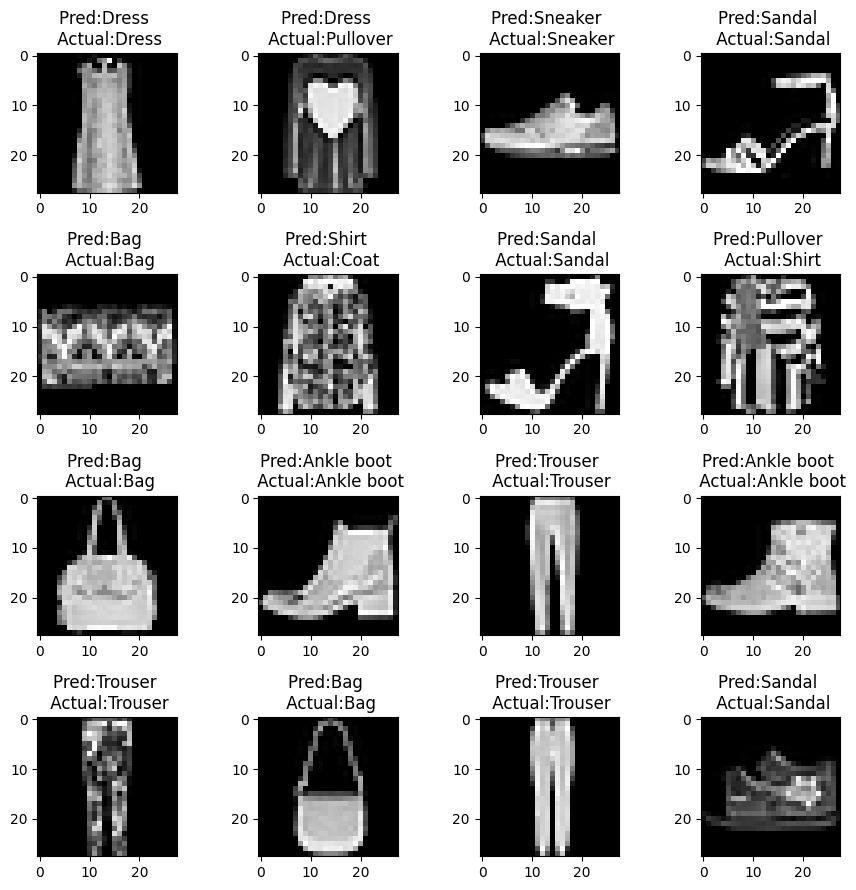

In [173]:
fig, axes = plt.subplots(4, 4, figsize  = (9,9))
test_pred = test_pred.to("cpu")
y = y.to("cpu")
X = X.to("cpu")
for i, ax in enumerate(axes.flatten()):
    
    ax.imshow(X[i].squeeze(), cmap = "gray")
    ax.set_title(f"Pred:{class_names[test_pred.argmax(dim=1)[i].item()]} \n Actual:{class_names[y[i].item()]}" )
plt.tight_layout()
